# UNSW-NB15 Preprocessing Notebook
This notebook preprocesses UNSW-NB15 data into a model-ready format.

## Pipeline summary
1. Load raw UNSW training data.
2. Inspect schema and **multi-class** distribution (`attack_cat`).
3. Drop non-informative columns (`id`, `label`) and duplicate rows.
4. Encode categorical features (`proto`, `service`, `state`).
5. Encode target column (`attack_cat`) with LabelEncoder.
6. Normalize numeric **features only** (not the target).
7. Perform train/test split with stratification.
8. Visualize class balance and correlations.
9. Export cleaned dataset to `../data_processed/unsw_nb15_cleaned.csv`.

## Step A: Load and Inspect
These cells load UNSW-NB15 data and inspect schema/summary statistics.
Use this stage to confirm expected columns and **attack category** labels before transformations.

In [1]:
import pandas as pd

df = pd.read_csv("../data_raw/unsw_nb15/UNSW_NB15_training-set.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (175341, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  str    
 3   service            175341 non-null  str    
 4   state              175341 non-null  str    
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  sinpkt       

In [3]:
df.describe()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,1.753410e+05,175341.000000,175341.000000,1.753410e+05,...,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,87671.000000,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04,9.540619e+04,179.546997,79.609567,7.345403e+07,...,5.383538,4.206255,8.729881,0.014948,0.014948,0.133066,6.955789,9.100758,0.015752,0.680622
std,50616.731112,6.480249,136.887597,110.258271,1.747656e+05,1.436542e+05,1.654010e+05,102.940011,110.506863,1.883574e+08,...,8.047104,5.783585,10.956186,0.126048,0.126048,0.701208,8.321493,10.756952,0.124516,0.466237
min,1.000000,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,43836.000000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,3.278614e+01,62.000000,0.000000,1.305334e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,87671.000000,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02,3.225807e+03,254.000000,29.000000,8.796748e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000,1.000000
75%,131506.000000,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03,1.250000e+05,254.000000,252.000000,8.888889e+07,...,5.000000,3.000000,12.000000,0.000000,0.000000,0.000000,9.000000,12.000000,0.000000,1.000000
max,175341.000000,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,...,51.000000,46.000000,65.000000,4.000000,4.000000,30.000000,60.000000,62.000000,1.000000,1.000000


In [4]:
# Multi-class distribution based on attack_cat
# Strip whitespace from attack_cat values first (raw data sometimes has leading/trailing spaces)
df['attack_cat'] = df['attack_cat'].str.strip()

print("=== Attack Category Distribution ===")
print(df['attack_cat'].value_counts())
print(f"\nTotal categories: {df['attack_cat'].nunique()}")
print(f"Unique categories: {sorted(df['attack_cat'].unique())}")

=== Attack Category Distribution ===
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

Total categories: 10
Unique categories: ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']


## Step B: Clean and Transform
This stage drops non-informative columns, encodes categorical features, and removes duplicates.

**Key change**: We drop both `id` and `label` columns. The `label` column (binary 0/1) is no longer needed because we use `attack_cat` for multi-class classification.

In [5]:
# Drop non-informative columns: id and binary label
df = df.drop(columns=["id", "label"])
print(f"Columns after dropping id and label: {list(df.columns)}")

Columns after dropping id and label: ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat']


In [6]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical FEATURES (not the target)
le_proto = LabelEncoder()
le_service = LabelEncoder()
le_state = LabelEncoder()

df["proto"] = le_proto.fit_transform(df["proto"])
df["service"] = le_service.fit_transform(df["service"])
df["state"] = le_state.fit_transform(df["state"])

print("Categorical features encoded: proto, service, state")

Categorical features encoded: proto, service, state


In [7]:
# Remove duplicate rows
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Removed {before - after} duplicate rows. Remaining: {after}")

Removed 67601 duplicate rows. Remaining: 107740


## Step C: Encode Target and Scale Features
1. Encode `attack_cat` into integer labels using `LabelEncoder`.
2. Apply `MinMaxScaler` only to feature columns (not the target).

**Important**: The target column should never be scaled.

In [8]:
# Encode the target column: attack_cat
le_target = LabelEncoder()
df["attack_cat"] = le_target.fit_transform(df["attack_cat"])

# Print the encoding mapping for reference
print("=== attack_cat Encoding Mapping ===")
for i, cls in enumerate(le_target.classes_):
    count = (df['attack_cat'] == i).sum()
    print(f"  {i} -> {cls} ({count} samples)")
print(f"\nTotal classes: {len(le_target.classes_)}")

=== attack_cat Encoding Mapping ===
  0 -> Analysis (1594 samples)
  1 -> Backdoor (1535 samples)
  2 -> DoS (3806 samples)
  3 -> Exploits (19844 samples)
  4 -> Fuzzers (16150 samples)
  5 -> Generic (4181 samples)
  6 -> Normal (51890 samples)
  7 -> Reconnaissance (7522 samples)
  8 -> Shellcode (1091 samples)
  9 -> Worms (127 samples)

Total classes: 10


In [9]:
from sklearn.preprocessing import MinMaxScaler

# Scale features only (exclude attack_cat target column)
feature_cols = [c for c in df.columns if c != "attack_cat"]
scaler = MinMaxScaler()

df[feature_cols] = scaler.fit_transform(df[feature_cols])
print(f"Scaled {len(feature_cols)} feature columns to [0, 1] range.")
print(f"Feature columns: {feature_cols}")

Scaled 42 feature columns to [0, 1] range.
Feature columns: ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']


## Step D: Train/Test Split
Split with `stratify=y` to preserve multi-class proportions across train and test sets.

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop("attack_cat", axis=1)
y = df["attack_cat"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
print(y_train.value_counts().sort_index())
print(f"\nTest set class distribution:")
print(y_test.value_counts().sort_index())

Training set: 75418 samples
Test set:     32322 samples

Training set class distribution:
attack_cat
0     1116
1     1074
2     2664
3    13891
4    11305
5     2927
6    36323
7     5265
8      764
9       89
Name: count, dtype: int64

Test set class distribution:
attack_cat
0      478
1      461
2     1142
3     5953
4     4845
5     1254
6    15567
7     2257
8      327
9       38
Name: count, dtype: int64


## Step E: Visualize Class Balance and Correlations
Plots and class reports showing multi-class imbalance, which is critical for IDS datasets.

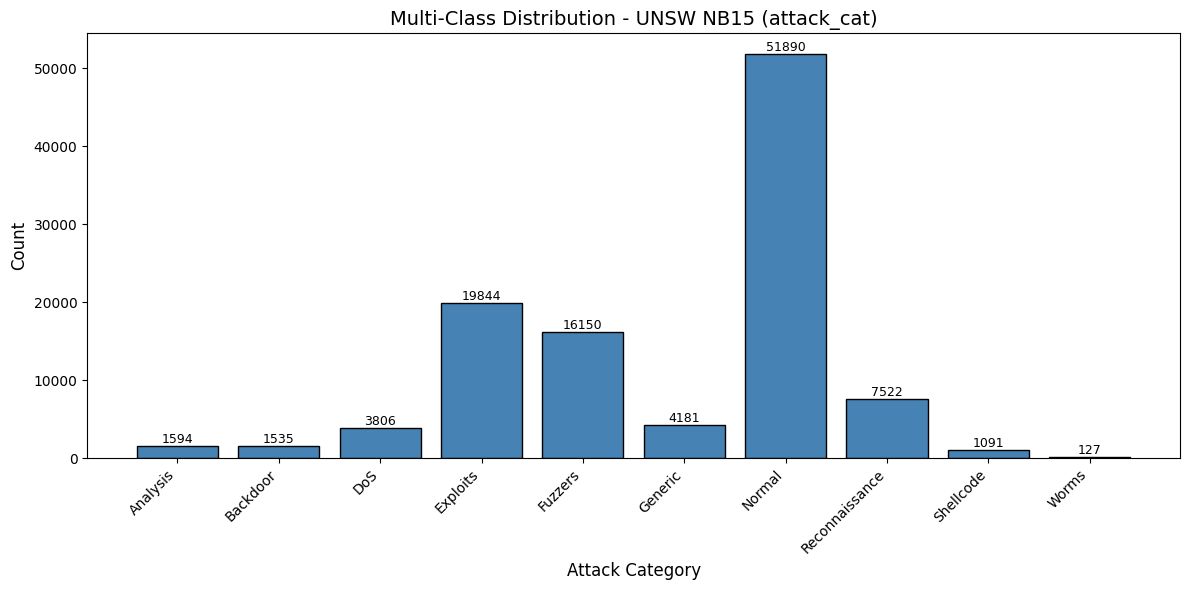

In [11]:
import matplotlib.pyplot as plt

# Multi-class distribution bar chart
class_counts = df["attack_cat"].value_counts().sort_index()
class_labels = [le_target.classes_[i] for i in class_counts.index]

plt.figure(figsize=(12, 6))
bars = plt.bar(class_labels, class_counts.values, color='steelblue', edgecolor='black')
plt.title("Multi-Class Distribution - UNSW NB15 (attack_cat)", fontsize=14)
plt.xlabel("Attack Category", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add count labels on top of bars
for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{count}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [12]:
# Multi-class imbalance report
import os

class_counts = df["attack_cat"].value_counts().sort_values(ascending=False)
total_samples = class_counts.sum()
minority_class_idx = class_counts.idxmin()
majority_class_idx = class_counts.idxmax()
minority_count = class_counts.min()
majority_count = class_counts.max()

minority_percentage = (minority_count / total_samples) * 100
imbalance_ratio = majority_count / minority_count

print(f"Minority class: {le_target.classes_[minority_class_idx]} (encoded={minority_class_idx})")
print(f"Minority class count: {minority_count}")
print(f"Minority class percentage: {minority_percentage:.4f}%")
print(f"\nMajority class: {le_target.classes_[majority_class_idx]} (encoded={majority_class_idx})")
print(f"Majority class count: {majority_count}")
print(f"\nImbalance ratio (majority/minority): {imbalance_ratio:.4f}")

print("\n=== Per-Class Report ===")
class_report = pd.DataFrame({
    'class_name': [le_target.classes_[i] for i in class_counts.index],
    'encoded': class_counts.index,
    'count': class_counts.values,
    'percentage': (class_counts.values / total_samples * 100).round(4)
})
class_report

Minority class: Worms (encoded=9)
Minority class count: 127
Minority class percentage: 0.1179%

Majority class: Normal (encoded=6)
Majority class count: 51890

Imbalance ratio (majority/minority): 408.5827

=== Per-Class Report ===


,class_name,encoded,count,percentage
0,Normal,6,51890,48.1622
1,Exploits,3,19844,18.4184
2,Fuzzers,4,16150,14.9898
3,Reconnaissance,7,7522,6.9816
4,Generic,5,4181,3.8806
5,DoS,2,3806,3.5326
6,Analysis,0,1594,1.4795
7,Backdoor,1,1535,1.4247
8,Shellcode,8,1091,1.0126
9,Worms,9,127,0.1179


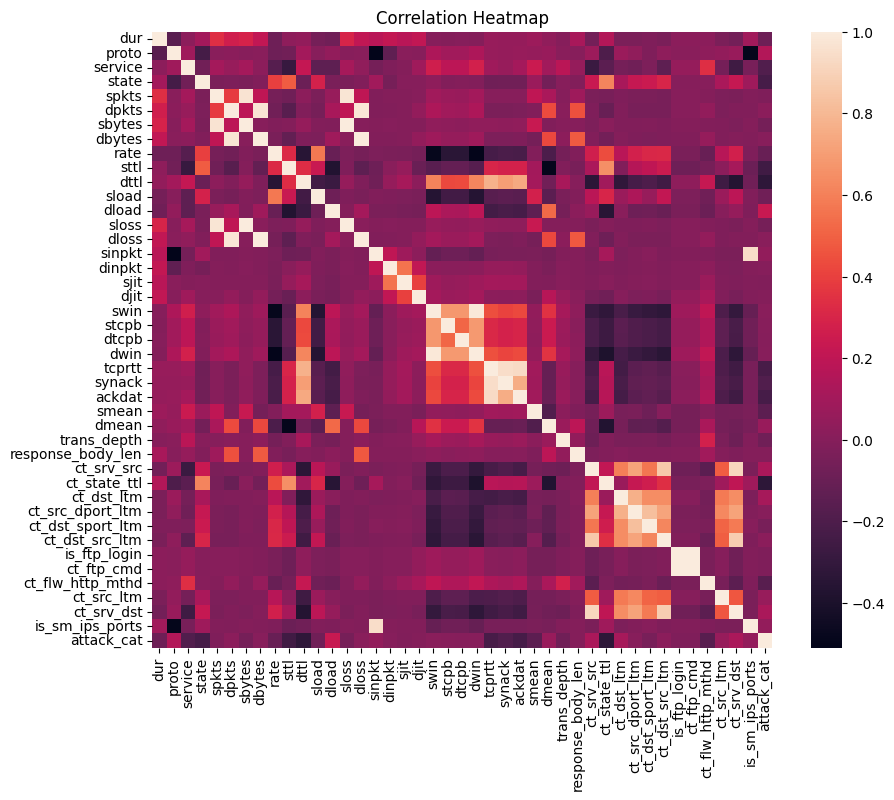

In [13]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr())
plt.title("Correlation Heatmap")
plt.show()

## Step F: Export Cleaned Dataset
The exported CSV uses integer-encoded `attack_cat` as the target column.

Downstream notebooks should use `attack_cat` as the target column `y`.

In [14]:
df.to_csv("../data_processed/unsw_nb15_cleaned.csv", index=False)
print(f"Saved cleaned dataset to ../data_processed/unsw_nb15_cleaned.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nTarget column: attack_cat")
print(f"Number of classes: {df['attack_cat'].nunique()}")

Saved cleaned dataset to ../data_processed/unsw_nb15_cleaned.csv
Shape: (107740, 43)
Columns: ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat']

Target column: attack_cat
Number of classes: 10
